In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap

import pylbsr.notebooks
import pylbsr.misc

import torch
from parnet_additional_utils import GzListDataset
from scipy.stats import pearsonr, spearmanr
import numpy as np

import parnet
from parnet_additional_utils import load_parnet_model, ParnetModelName
from parnet.layers import LinearProjectionHead
from parnet.utils import count_trainable_params

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


In [2]:
_notebook_name = "99_evaluate_runs.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[20:13:30] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [5]:
# ── Runs to compare ────────────────────────────────────────────────────────────
# Add or remove run names here to include/exclude from the comparison plots.
RUNS = [
    "parnet.7m-0.0.head.globalclip-lysate-noNHS.noctrl",
    "parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.noctrl",
]

RUNS_DIR = PROJECT_DIR / "results" / "globalclip-head" / "training"

⏱ 0.00 s (00:00:00)


In [6]:
def load_run(run_name):
    run_dir = RUNS_DIR / run_name
    csv_path = sorted((run_dir / "csv_logs").glob("version_*/metrics.csv"))[-1] # load latest version of the model
    df = pd.read_csv(csv_path)
    val   = df[['epoch', 'val/loss']].dropna(subset=['val/loss'])
    train = df[['epoch', 'train/loss_eCLIP_epoch']].dropna(subset=['train/loss_eCLIP_epoch'])
    summary = val.merge(train, on='epoch')
    summary['run'] = run_name
    return summary

runs_data = {run: load_run(run) for run in RUNS}
logger.info(f"Loaded {len(runs_data)} runs")
for name, df in runs_data.items():
    logger.info(f"  {name}: {len(df)} epochs")

[12:53:46] INFO - Loaded 2 runs
[12:53:46] INFO -   parnet.7m-0.0.head.globalclip-lysate-noNHS.noctrl: 10 epochs
[12:53:46] INFO -   parnet.7m-0.0.unfreeze_last_2_layers.globalclip-lysate-noNHS.noctrl: 30 epochs


⏱ 0.11 s (00:00:00)


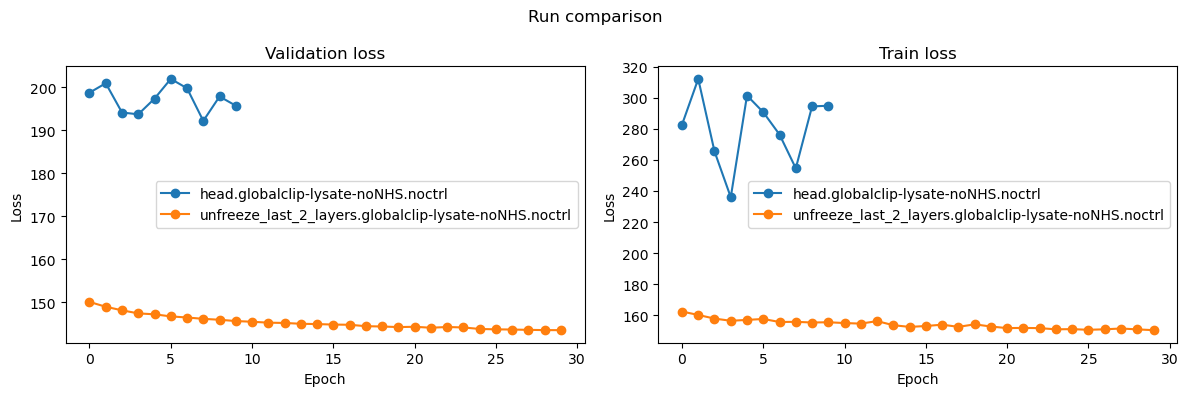

⏱ 0.81 s (00:00:00)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for run_name, df in runs_data.items():
    label = run_name.replace("parnet.7m-0.0.", "")
    axes[0].plot(df['epoch'], df['val/loss'], marker='o', label=label)
    axes[1].plot(df['epoch'], df['train/loss_eCLIP_epoch'], marker='o', label=label)

axes[0].set_title('Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Train loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Run comparison')
plt.tight_layout()

# ── Save to run folder and central figures dir ─────────────────────────────────
_figures_dir = PROJECT_DIR / "results" / "globalclip-head" / "figures"
_figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(RUNS_DIR / "comparison.png", dpi=150, bbox_inches="tight")
plt.savefig(_figures_dir / "loss_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Summary table ──────────────────────────────────────────────────────────────
rows = []
for run_name, df in runs_data.items():
    label = run_name.replace("parnet.7m-0.0.", "")
    best_epoch = df.loc[df['val/loss'].idxmin()]
    rows.append({
        "run": label,
        "best_epoch": int(best_epoch['epoch']),
        "best_val_loss": round(best_epoch['val/loss'], 3),
        "final_train_loss": round(df.iloc[-1]['train/loss_eCLIP_epoch'], 3),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

                                                  run  best_epoch  best_val_loss  final_train_loss
                  head.globalclip-lysate-noNHS.noctrl           7        192.231           294.955
unfreeze_last_2_layers.globalclip-lysate-noNHS.noctrl          29        143.536           150.315
⏱ 0.01 s (00:00:00)


RUN ONE MODEL ON TEST DATASET

In [3]:
### RUN ON TEST DATASET AND CALCULATE CORRELATIONS

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

[20:13:38] INFO - Using device: cuda:0


⏱ 0.02 s (00:00:00)


In [6]:
# ── Select which run to evaluate on which test set ───────────────────────────────────
EVAL_RUN = "parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.raw.noctrl.ep50" # ADAPT 

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())
DATA_PATH = Path(_fp_cfg["global_clip"]["data_lysate_noNHS"]) # ADAPT - filtered or unfiltered data

logger.info(f"Evaluating run: {EVAL_RUN}")
logger.info(f"Test data: {DATA_PATH}")

RUNS_DIR = PROJECT_DIR / "results" / "globalclip-head" / "training"

[20:16:19] INFO - Evaluating run: parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.raw.noctrl.ep50
[20:16:19] INFO - Test data: /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/globalclip_lysate_noNHS_600bp_signalfiltered.pt


⏱ 0.01 s (00:00:00)


In [7]:
# ── Load test dataset ──────────────────────────────────────────────────────────
test_ds = GzListDataset(
    DATA_PATH, split="test",
    length=600, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)
logger.info(f"Test size: {len(test_ds)}")

# ── Load best model ────────────────────────────────────────────────────────────
_model_path = RUNS_DIR / EVAL_RUN / "model.statedict.pt"
checkpoint = torch.load(_model_path, map_location=device)
logger.info(f"Loaded model from: {_model_path}")
logger.info(f"Model config: {checkpoint['model_config']}")

Loading (mmap) globalclip_lysate_noNHS_600bp_signalfiltered.pt split='test'... 

[20:16:32] INFO - Test size: 4946


loaded 4946 samples.


[20:16:33] INFO - Loaded model from: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.raw.noctrl.ep50/model.statedict.pt
[20:16:33] INFO - Model config: {'parnet_model_name': 'parnet.7m-0.0', 'head': 'GlobalCLIPHead', 'num_tasks': 1, 'finetuning_strategy': 'unfreeze_last_n_layers', 'use_control': False}


⏱ 10.88 s (00:00:10)


In [8]:
# ── Rebuild model architecture ─────────────────────────────────────────────────
pretrained_model_name = ParnetModelName.PARNET_7M_0_0
_pretrained_path = Path(_fp_cfg["models"][pretrained_model_name.value])

model = load_parnet_model(
    pretrained_model_name,
    _pretrained_path,
    dtype=torch.float32,
    device=device,
)

# Replace head with GlobalCLIPHead (same as training notebook)
class GlobalCLIPHead(torch.nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        logit = self.projection(inputs)
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model.head = GlobalCLIPHead(num_tasks=1).to(device)

# Initialize lazy parameters
with torch.no_grad():
    _dummy = torch.zeros(1, 512, 600, device=device)
    model.head(_dummy)

# Load fine-tuned weights
model.load_state_dict(checkpoint["state_dict"])
model.eval()
logger.info(f"Model ready — params: {count_trainable_params(model):,}")

[20:17:12] INFO - Model ready — params: 7,118,336


⏱ 0.53 s (00:00:00)


In [9]:
# ── Run inference on test set ──────────────────────────────────────────────────
pearson_scores = []
spearman_scores = []

model.eval()
with torch.no_grad():
    for i in range(len(test_ds)):
        sample = test_ds[i]
        
        # prepare input
        seq = sample["inputs"]["sequence"].unsqueeze(0).to(device)  # (1, 4, 600)
        
        # forward pass
        y_pred = model(sequence=seq)
        pred = y_pred["total"].squeeze().cpu().numpy()  # (600,)
        
        # get target signal
        target = sample["outputs"]["total"].squeeze().cpu().numpy()  # (600,)
        
        # skip windows where target is all zeros
        if target.sum() == 0:
            continue
        
        # compute correlations
        pearson_scores.append(pearsonr(pred, target)[0])
        spearman_scores.append(spearmanr(pred, target)[0])

print(f"Test samples evaluated: {len(pearson_scores)}")
print(f"Pearson  — mean: {np.mean(pearson_scores):.4f}  median: {np.median(pearson_scores):.4f}")
print(f"Spearman — mean: {np.mean(spearman_scores):.4f}  median: {np.median(spearman_scores):.4f}")

/home/lhofer/pixi-envs/parnet--globalclip-head-6013472398032450694/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


Test samples evaluated: 4946
Pearson  — mean: 0.2442  median: 0.2334
Spearman — mean: 0.2798  median: 0.2636
⏱ 13.33 s (00:00:13)


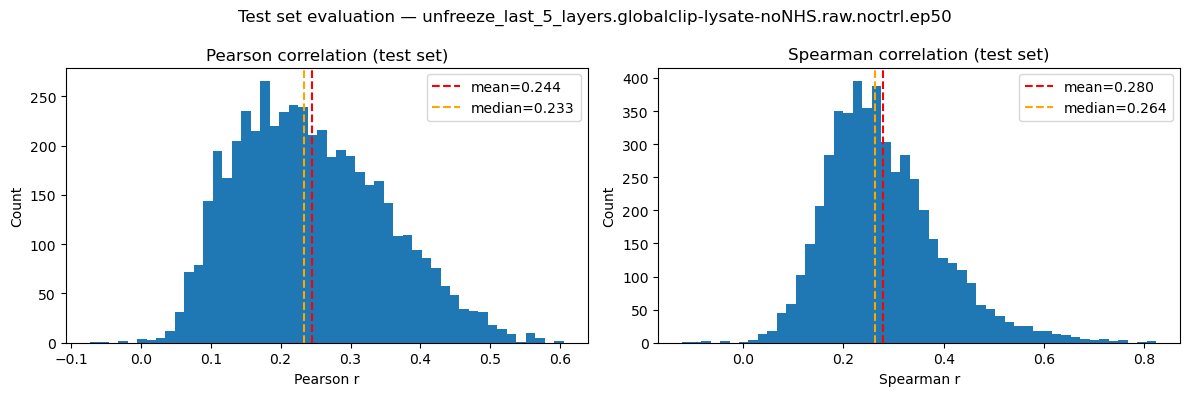

⏱ 0.88 s (00:00:00)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pearson_scores, bins=50)
axes[0].axvline(np.mean(pearson_scores), color='red', linestyle='--', label=f'mean={np.mean(pearson_scores):.3f}')
axes[0].axvline(np.median(pearson_scores), color='orange', linestyle='--', label=f'median={np.median(pearson_scores):.3f}')
axes[0].set_title('Pearson correlation (test set)')
axes[0].set_xlabel('Pearson r')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(spearman_scores, bins=50)
axes[1].axvline(np.mean(spearman_scores), color='red', linestyle='--', label=f'mean={np.mean(spearman_scores):.3f}')
axes[1].axvline(np.median(spearman_scores), color='orange', linestyle='--', label=f'median={np.median(spearman_scores):.3f}')
axes[1].set_title('Spearman correlation (test set)')
axes[1].set_xlabel('Spearman r')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle(f"Test set evaluation — {EVAL_RUN.replace('parnet.7m-0.0.', '')}")
plt.tight_layout()

# ── Save to run folder and central figures dir ─────────────────────────────────
_figures_dir = PROJECT_DIR / "results" / "globalclip-head" / "figures"
_figures_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(RUNS_DIR / EVAL_RUN / "test_correlations.png", dpi=150, bbox_inches="tight")
plt.savefig(_figures_dir / f"test_correlations.{EVAL_RUN.replace('parnet.7m-0.0.', '')}.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Save summary statistics ────────────────────────────────────────────────────
eval_results = {
    "run": EVAL_RUN,
    "n_test_samples": len(pearson_scores),
    "pearson_mean": round(float(np.mean(pearson_scores)), 4),
    "pearson_median": round(float(np.median(pearson_scores)), 4),
    "spearman_mean": round(float(np.mean(spearman_scores)), 4),
    "spearman_median": round(float(np.median(spearman_scores)), 4),
}

_eval_path = RUNS_DIR / EVAL_RUN / "test_evaluation.yaml"
_eval_path.write_text(yaml.dump(eval_results, default_flow_style=False))

# ── Save full per-sequence distributions ───────────────────────────────────────
np.save(RUNS_DIR / EVAL_RUN / "test_pearson_scores.npy", np.array(pearson_scores))
np.save(RUNS_DIR / EVAL_RUN / "test_spearman_scores.npy", np.array(spearman_scores))

logger.info(f"Saved evaluation results → {_eval_path}")
print(pd.DataFrame([eval_results]).to_string(index=False))

[20:20:38] INFO - Saved evaluation results → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.raw.noctrl.ep50/test_evaluation.yaml


                                                                         run  n_test_samples  pearson_mean  pearson_median  spearman_mean  spearman_median
parnet.7m-0.0.unfreeze_last_5_layers.globalclip-lysate-noNHS.raw.noctrl.ep50            4946        0.2442          0.2334         0.2798           0.2636
⏱ 0.03 s (00:00:00)
